In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import multifractal_functions as mf
import tda_functions as tda
import utils as ut

from datasets import load_dataset
import pandas as pd
import os
import pickle
import time

In [3]:
path_data = '/Users/jardigarcia/Documents/DATASETS/ART/wikiart_dataset'  # MacBook
ds = load_dataset(path_data)['train']
N = len(ds)

Resolving data files:   0%|          | 0/69 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/66 [00:00<?, ?it/s]

In [6]:
artistas = ds.features['artist'].names
movimientos = ds.features['style'].names
generos = ds.features['genre'].names

dic_metadata = {'id':[],'autor':[],'movimiento':[],'genero':[]}
for i,item in enumerate(ds):
    dic_metadata['id'].append(i)
    dic_metadata['autor'].append(artistas[int(item['artist'])])
    dic_metadata['movimiento'].append(movimientos[int(item['style'])])
    dic_metadata['genero'].append(generos[int(item['genre'])])

    

df_metadata = pd.DataFrame(dic_metadata).set_index('id')
np.savez(os.path.join('DATA','metadata'), data = dic_metadata, allow_pickle=True)

In [7]:
ids_errors = []
path_save = 'DATA/features'

In [39]:
q_min = -10
q_max = 10


dic_features = {'ids':[]}
save_every = 1
count_saves = 0

count = 0
for id in range(N):
    item = ds[id]

    try:
        img = np.array(item['image'])
        img_norm = ut.normalize_image(img=img, max_size=1380, gray=True)
        for n_segments in range(1,4):
            print('Numero de segmentos : ',n_segments)
            list_images = ut.segment_image(img_norm, grid_size=n_segments)
            for p_segment,img_seg in enumerate(list_images):
                print(p_segment)
                data_dfa, features_dfa = mf.mf_dfa(img=img_seg, 
                                                   q_min=q_min, 
                                                   q_max=q_max, 
                                                   s_min=0.25,
                                                   s_max=0.75, 
                                                   integration=True, 
                                                   degree_trend = 2, 
                                                   degree_scales = 2)
                data_renyi, features_renyi = mf.mf_renyi(img=img_seg, 
                                                         q_min=q_min, 
                                                         q_max=q_max, 
                                                         s_min=0.008,
                                                         s_max=0.25, 
                                                         degree_scales=2)
                data_tda, features_tda = tda.tda_features(img=img, step=5)

                # Guarda características DFA
                for key in features_dfa.keys():
                    name_feature = f'{n_segments}__{p_segment}__' + key
                    if name_feature not in dic_features.keys():
                        dic_features[name_feature] = [features_dfa[key]]
                    else:
                        dic_features[name_feature].append(features_dfa[key])
                
                # Guarda características Renyi
                for key in features_renyi.keys():
                    name_feature = f'{n_segments}__{p_segment}__' + key
                    if name_feature not in dic_features.keys():
                        dic_features[name_feature] = [features_renyi[key]]
                    else:
                        dic_features[name_feature].append(features_renyi[key])

                # Guarda características TDA
                for key in features_tda.keys():
                    name_feature = f'{n_segments}__{p_segment}__' + key
                    if name_feature not in dic_features.keys():
                        dic_features[name_feature] = [features_tda[key]]
                    else:
                        dic_features[name_feature].append(features_tda[key])

        dic_features['ids'].append(id)

    except:
        ids_errors.append(id)
        
    count += 1
    if count % save_every == 0:
        count_saves += 1
        file_name = f'{count_saves}.pkl'
        with open(os.path.join(path_save,file_name), 'wb') as f:
            pickle.dump(dic_features, f)
        dic_features = {'ids':[]} # Reinicia diccionario
        print(f"Guardado {count_saves} de imagen {count}")
        break
 

Numero de segmentos :  1
0
Guardado 1 de imagen 1


In [ ]:
count_saves += 1
file_name = f'{count_saves}.pkl'
with open(os.path.join(path_save,file_name), 'wb') as f:
    pickle.dump(dic_features, f)

In [33]:
img_seg.shape

(1380, 1380)

In [37]:
dic_features

{'ids': []}

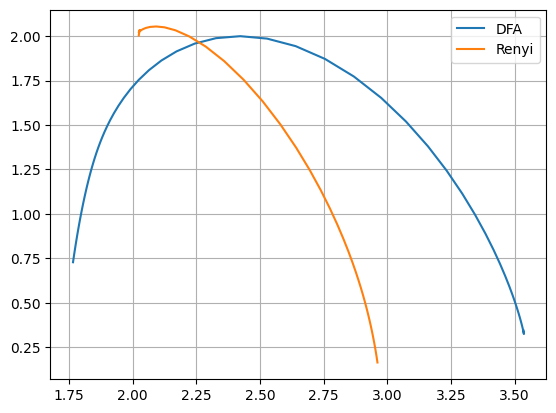

In [32]:
# plt.plot(data_cascade['alpha'],data_cascade['f_alpha'], label = 'Teórico')
plt.plot(data_dfa['alpha'], data_dfa['f_alpha'],label = 'DFA')
plt.plot(data_renyi['alpha'], data_renyi['f_alpha'],label = 'Renyi')

plt.legend()
plt.grid()
plt.show()

